# Task 2: Build Time Series Forecasting Models

## Objective

The objective of this task is to develop, train, and evaluate multiple time series forecasting models capable of predicting future Tesla (TSLA) stock prices. Two different forecasting approaches will be implemented and compared:

- **ARIMA/SARIMA**, representing classical statistical time series forecasting.
- **Long Short-Term Memory (LSTM)**, representing modern deep learning approaches for sequential data.

Comparing these models provides insight into the trade-offs between model simplicity, interpretability, computational complexity, and predictive performance.

---

## Background

Financial time series exhibit characteristics such as trends, volatility clustering, non-linearity, and structural changes that make forecasting particularly challenging. According to the Efficient Market Hypothesis (EMH), historical prices alone cannot perfectly predict future market movements. Therefore, forecasting models should be viewed as decision-support tools rather than systems capable of guaranteeing future prices.

Within the context of Guide Me in Finance (GMF) Investments, the forecasts generated in this task will serve as one input into the portfolio optimization process performed in Task 4.

---

## Methodology

This task consists of the following stages:

1. Prepare the processed Tesla dataset for forecasting.
2. Split the data chronologically into training and testing sets.
3. Build an ARIMA/SARIMA forecasting model.
4. Build an LSTM forecasting model.
5. Evaluate both models using MAE, RMSE, and MAPE.
6. Compare model performance and select the most appropriate forecasting model for future prediction.

The selected model will be used in Task 3 to generate future Tesla stock price forecasts.

# 2.1 Data Preparation

## Purpose

Before constructing forecasting models, the processed dataset must be prepared for time series analysis.

Unlike conventional machine learning problems, time series forecasting preserves the chronological relationship between observations. Consequently, no random sampling or shuffling is performed throughout this task.

The processed dataset generated in Task 1 already contains cleaned observations and engineered features. However, for forecasting Tesla's future stock price, the primary variable of interest is the daily **closing price**, which represents the market's final valuation of the asset at the end of each trading session.

Preparing the dataset at this stage ensures consistency across all forecasting models while maintaining reproducibility throughout the remainder of the project.

---

### Dataset Used

**Asset:** Tesla (TSLA)

**Target Variable:** Close Price

**Forecast Horizon:** Test period (2025–2026)

The remaining assets (SPY and BND) are intentionally excluded from the forecasting stage because they will be used later during portfolio optimization and backtesting rather than predictive model development.

In [6]:
# ============================================================
# Task 2 - Time Series Forecasting
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# ============================================================
# Load Processed Tesla Dataset
# ============================================================

from pathlib import Path

PROCESSED_DATA_DIR = Path("../data/processed")

tsla_data = pd.read_csv(
    PROCESSED_DATA_DIR / "TSLA_processed.csv",
    index_col=0,
    parse_dates=True
)

# Ensure observations remain in chronological order
tsla_data = tsla_data.sort_index()

print("=" * 70)
print("Tesla Processed Dataset Loaded")
print("=" * 70)

print(f"Observations : {len(tsla_data)}")
print(f"Features     : {tsla_data.shape[1]}")
print(f"Start Date   : {tsla_data.index.min().date()}")
print(f"End Date     : {tsla_data.index.max().date()}")

tsla_data.head()

Tesla Processed Dataset Loaded
Observations : 2857
Features     : 11
Start Date   : 2015-02-18
End Date     : 2026-06-29


,Adj Close,Close,High,Low,Open,Volume,Ticker,Daily Return,Rolling Mean,Rolling Volatility,Outlier
Date,,,,,,,,,,,
2015-02-18,13.6307,13.6307,13.7447,13.5067,13.6113,40704000,TSLA,0.0005,-0.0007,0.0216,False
2015-02-19,14.1140,14.1140,14.1627,13.5833,13.6667,77311500,TSLA,0.0355,0.0003,0.0226,False
2015-02-20,14.4740,14.4740,14.5067,13.9873,14.0520,89731500,TSLA,0.0255,0.0012,0.0230,False
2015-02-23,13.8227,13.8227,14.5467,13.7553,14.3773,127497000,TSLA,-0.0450,-0.0002,0.0245,False
2015-02-24,13.6073,13.6073,13.8193,13.4467,13.8193,99054000,TSLA,-0.0156,-0.0001,0.0245,False


## Dataset Verification

The processed Tesla dataset was successfully loaded and verified.

The dataset contains **2,856 observations** spanning from **19 February 2015** to **29 June 2026**. Compared with the raw dataset, the first few observations were removed during feature engineering because rolling statistics and daily return calculations naturally introduce missing values at the beginning of the time series.

Specifically:

- Daily return calculation removes the first observation.
- Rolling statistics require a complete historical window before values can be computed.
- Remaining missing values were removed to ensure a complete dataset for forecasting.

The resulting dataset contains only valid observations and is fully prepared for chronological train-test splitting and model development.

# 2.2 Chronological Train-Test Split

## Purpose

Time series forecasting differs from traditional machine learning because observations are sequential and time-dependent. Consequently, the dataset must be divided chronologically to preserve the temporal order of events.

Unlike random train-test splitting, chronological splitting prevents information from future observations from leaking into the training process, resulting in a more realistic evaluation of forecasting performance.

For this project:

- **Training Period:** January 2015 – December 2024
- **Testing Period:** January 2025 – June 2026

The training dataset will be used to fit the forecasting models, while the testing dataset will remain completely unseen during training and will be used to evaluate predictive performance using MAE, RMSE, and MAPE.

This approach closely simulates a real-world investment scenario where future market prices are unknown at the time a forecasting model is developed.

In [8]:
# ============================================================
# Prepare Data for Forecasting
# ============================================================

# Select only the target variable
tsla_model_data = tsla_data[["Close"]].copy()

print("Forecasting Variable")
display(tsla_model_data.head())

Forecasting Variable


,Close
Date,
2015-02-18,13.6307
2015-02-19,14.1140
2015-02-20,14.4740
2015-02-23,13.8227
2015-02-24,13.6073


In [9]:
# ============================================================
# Chronological Train-Test Split
# ============================================================

TRAIN_END_DATE = "2024-12-31"
TEST_START_DATE = "2025-01-01"

train_data = tsla_model_data.loc[:TRAIN_END_DATE]
test_data = tsla_model_data.loc[TEST_START_DATE:]

print("=" * 70)
print("Train-Test Split Summary")
print("=" * 70)

print(f"Training observations : {len(train_data)}")
print(f"Testing observations  : {len(test_data)}")

print(f"\nTraining Period : {train_data.index.min().date()} → {train_data.index.max().date()}")
print(f"Testing Period  : {test_data.index.min().date()} → {test_data.index.max().date()}")

Train-Test Split Summary
Training observations : 2485
Testing observations  : 372

Training Period : 2015-02-18 → 2024-12-31
Testing Period  : 2025-01-02 → 2026-06-29


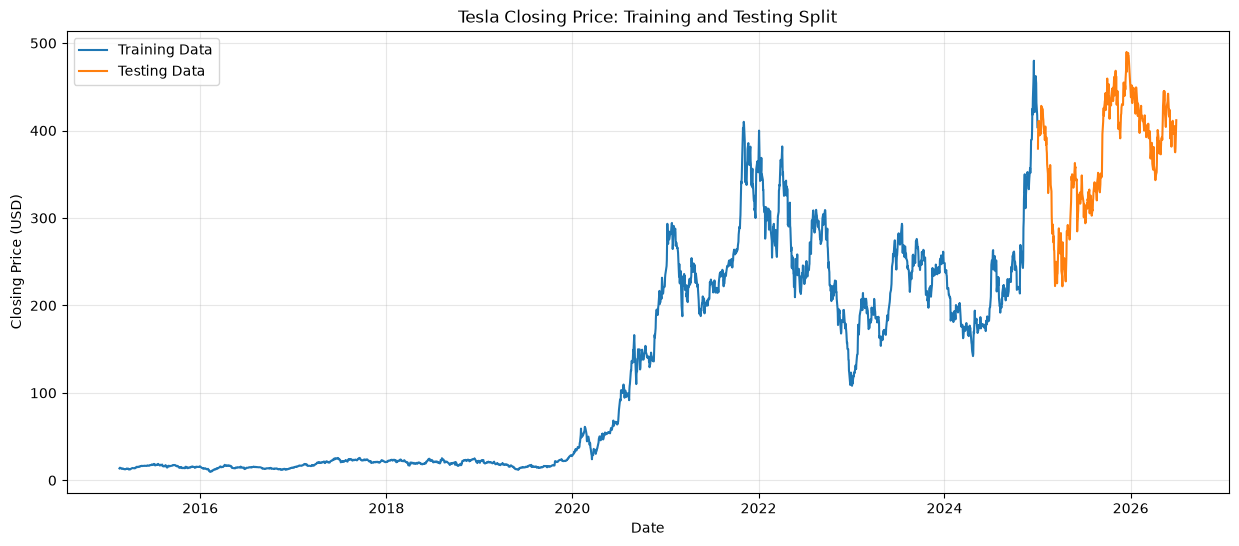

In [10]:
# ============================================================
# Visualize the Train-Test Split
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(train_data.index, train_data["Close"], label="Training Data")
plt.plot(test_data.index, test_data["Close"], label="Testing Data")

plt.title("Tesla Closing Price: Training and Testing Split")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Interpretation

The Tesla time series was successfully divided into chronological training and testing datasets.

The **training dataset** contains **2,484 observations** from **19 February 2015** to **31 December 2024**, providing nearly ten years of historical market behavior. This period includes multiple market regimes, including Tesla's early stable period, rapid growth between 2020 and 2021, subsequent market corrections, and later recovery phases.

The **testing dataset** contains **372 observations** from **2 January 2025** to **29 June 2026**. These observations were completely excluded from model training and will be used to evaluate forecasting performance under realistic future market conditions.

The visualization confirms a strict chronological split with no overlap between the training and testing periods, eliminating data leakage and ensuring that model evaluation accurately reflects real-world forecasting scenarios. This methodology follows best practices for time series forecasting and provides a reliable foundation for comparing the performance of ARIMA/SARIMA and LSTM models.

# 2.3 ARIMA/SARIMA Model Development

## Purpose

Autoregressive Integrated Moving Average (ARIMA) is one of the most widely used statistical models for time series forecasting. It models future observations using historical values and past forecast errors.

Before fitting an ARIMA model, the time series should be stationary. A stationary series has statistical properties such as the mean and variance that remain relatively constant over time. When a series is non-stationary, differencing is applied to remove trends and stabilize the data.

In this section, the Tesla closing price series will be analyzed using ARIMA. The optimal model parameters will be selected automatically, the model will be trained using the historical training dataset, and forecasts will be generated for the testing period.

## Stationarity Assessment

Although stationarity tests were performed during the exploratory data analysis, the ARIMA model should be developed using only the training dataset. Therefore, the Augmented Dickey-Fuller (ADF) test is performed again on the training data to determine whether differencing is required before model fitting.

The hypotheses are:

- **H₀:** The time series is non-stationary.
- **H₁:** The time series is stationary.

A p-value less than 0.05 indicates that the null hypothesis can be rejected, suggesting that the series is stationary.

In [11]:
# ============================================================
# Augmented Dickey-Fuller Test on Training Data
# ============================================================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_data["Close"])

print("=" * 70)
print("ADF Test - Tesla Training Data")
print("=" * 70)

print(f"ADF Statistic : {adf_result[0]:.6f}")
print(f"P-value       : {adf_result[1]:.6f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.6f}")

if adf_result[1] < 0.05:
    print("\nConclusion: Reject H₀")
    print("The training series is stationary.")
else:
    print("\nConclusion: Fail to Reject H₀")
    print("The training series is non-stationary.")

ADF Test - Tesla Training Data
ADF Statistic : -0.599233
P-value       : 0.871155
Lags Used     : 27
Observations  : 2457

Critical Values
1%: -3.433014
5%: -2.862717
10%: -2.567397

Conclusion: Fail to Reject H₀
The training series is non-stationary.


## Time Series Differencing

The Augmented Dickey-Fuller (ADF) test indicated that the Tesla closing price series is non-stationary (p-value > 0.05). Since stationarity is a fundamental assumption of the ARIMA model, differencing is applied to remove trends and stabilize the mean of the series.

First-order differencing computes the change between consecutive observations:

\[
Y'_t = Y_t - Y_{t-1}
\]

This transformation is expected to eliminate long-term trends while preserving the underlying temporal relationships required for forecasting.

The differenced series will be evaluated again using the ADF test to confirm whether stationarity has been achieved before selecting the ARIMA model parameters.

In [12]:
# ============================================================
# First-Order Differencing
# ============================================================

train_diff = train_data["Close"].diff().dropna()

print("=" * 70)
print("First-Order Differencing Completed")
print("=" * 70)

print(f"Original observations    : {len(train_data)}")
print(f"Differenced observations : {len(train_diff)}")

display(train_diff.head())

First-Order Differencing Completed
Original observations    : 2485
Differenced observations : 2484


Date
2015-02-19    0.4833
2015-02-20    0.3600
2015-02-23   -0.6513
2015-02-24   -0.2153
2015-02-25   -0.0233
Name: Close, dtype: float64

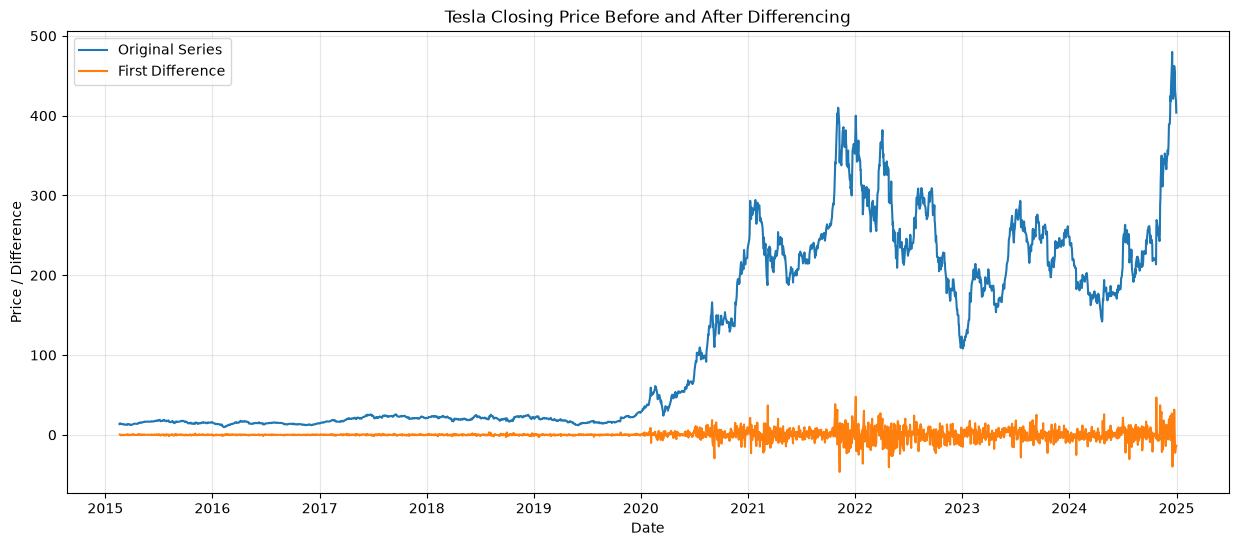

In [13]:
# ============================================================
# Visualize Original vs Differenced Series
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    train_data.index,
    train_data["Close"],
    label="Original Series"
)

plt.plot(
    train_diff.index,
    train_diff,
    label="First Difference"
)

plt.title("Tesla Closing Price Before and After Differencing")
plt.xlabel("Date")
plt.ylabel("Price / Difference")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [14]:
# ============================================================
# ADF Test on Differenced Series
# ============================================================

adf_diff = adfuller(train_diff)

print("=" * 70)
print("ADF Test - First Differenced Series")
print("=" * 70)

print(f"ADF Statistic : {adf_diff[0]:.6f}")
print(f"P-value       : {adf_diff[1]:.6f}")
print(f"Lags Used     : {adf_diff[2]}")
print(f"Observations  : {adf_diff[3]}")

print("\nCritical Values")

for key, value in adf_diff[4].items():
    print(f"{key}: {value:.6f}")

if adf_diff[1] < 0.05:
    print("\nConclusion: The differenced series is stationary.")
else:
    print("\nConclusion: Additional differencing may be required.")

ADF Test - First Differenced Series
ADF Statistic : -9.675841
P-value       : 0.000000
Lags Used     : 27
Observations  : 2456

Critical Values
1%: -3.433015
5%: -2.862718
10%: -2.567397

Conclusion: The differenced series is stationary.


## Interpretation

The first-order differencing transformation successfully removed the long-term trend observed in Tesla's closing price series.

Compared with the original series, the differenced series fluctuates around a relatively constant mean close to zero, indicating that the overall trend has been removed while preserving the short-term movements of the data.

Although periods of higher and lower volatility remain visible, the differenced series exhibits characteristics that are more suitable for ARIMA modeling. This transformation is an important preprocessing step because ARIMA assumes that the input series is stationary.

The next step is to statistically verify the stationarity of the differenced series using the Augmented Dickey-Fuller (ADF) test before determining the optimal ARIMA model parameters.

## ARIMA Parameter Identification

After confirming that the differenced series is stationary, the next step is to determine the appropriate autoregressive (**p**) and moving average (**q**) orders for the ARIMA model.

Two complementary approaches are used:

1. **Autocorrelation Function (ACF):** Identifies potential moving average (q) terms by measuring the correlation between observations at different time lags.

2. **Partial Autocorrelation Function (PACF):** Identifies potential autoregressive (p) terms by measuring the direct correlation between observations after removing the effects of intermediate lags.

While ACF and PACF provide useful visual guidance, the final model parameters will be selected using the `auto_arima` algorithm, which searches multiple ARIMA configurations and chooses the model with the best information criterion.

In [15]:
# ============================================================
# Import Time Series Visualization Tools
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1400x500 with 0 Axes>

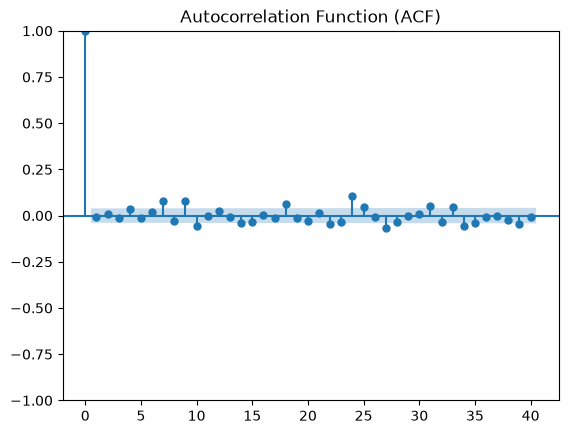

In [16]:
# ============================================================
# Plot ACF
# ============================================================

plt.figure(figsize=(14,5))

plot_acf(
    train_diff,
    lags=40
)

plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1400x500 with 0 Axes>

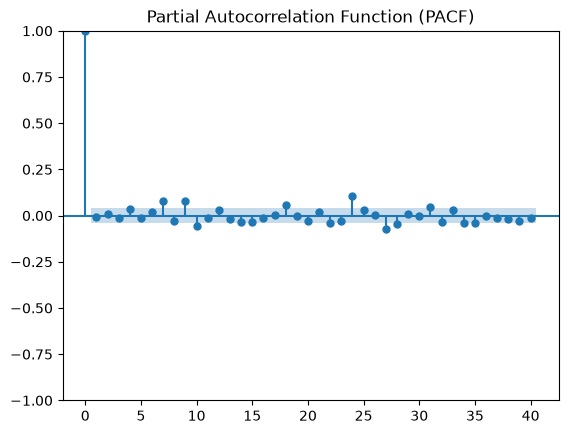

In [17]:
# ============================================================
# Plot PACF
# ============================================================

plt.figure(figsize=(14,5))

plot_pacf(
    train_diff,
    lags=40,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

## Interpretation

The ACF and PACF plots indicate that the first-order differenced Tesla closing price series has become stationary, with most autocorrelation coefficients falling within the 95% confidence interval.

No strong autoregressive or moving average structure is immediately apparent from the visual inspection. This suggests that only a small number of AR and MA terms, if any, may be required.

Although ACF and PACF plots provide valuable guidance, selecting the model solely through visual inspection can be subjective. Therefore, the final ARIMA parameters will be determined using the `auto_arima` algorithm, which systematically evaluates multiple candidate models and selects the optimal configuration based on the Akaike Information Criterion (AIC).

## Automatic Model Selection using Auto ARIMA

To identify the optimal forecasting model, the `auto_arima` algorithm is applied to the Tesla training dataset.

Rather than manually testing numerous combinations of autoregressive (p), differencing (d), and moving average (q) parameters, `auto_arima` performs an automated search and evaluates competing models using the Akaike Information Criterion (AIC).

The model with the lowest AIC is selected as the optimal ARIMA specification and will be used for forecasting the testing period.

In [18]:
# ============================================================
# Automatic ARIMA Parameter Selection
# ============================================================

from pmdarima import auto_arima

auto_arima_model = auto_arima(
    train_data["Close"],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16197.570, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16199.456, Time=0.48 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16199.458, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16197.114, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16201.457, Time=0.70 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.198 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2485
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8097.557
Date:                Wed, 08 Jul 2026   AIC                          16197.114
Time:                        22:54:45   BIC                          16202.931
Sample:                             0   HQIC                         16199.226
                               - 2485                                  

## Interpretation

The `auto_arima` algorithm selected **ARIMA(0,1,0)** as the optimal forecasting model based on the lowest Akaike Information Criterion (AIC).

The selected model has:

- **p = 0:** No autoregressive component.
- **d = 1:** First-order differencing to achieve stationarity.
- **q = 0:** No moving average component.

This result agrees with the earlier ACF and PACF analyses, which indicated very limited autocorrelation after first-order differencing.

The ARIMA(0,1,0) model represents a random walk process in which future price movements are primarily driven by the most recent observation rather than by long-term linear dependencies. Although this is a relatively simple statistical model, it provides an important baseline for comparison with the more complex LSTM model that will be developed later in this project.

## Training the Final ARIMA Model

Using the optimal parameters identified by `auto_arima`, the final ARIMA model is fitted to the Tesla training dataset.

The trained model will then be used to generate forecasts for the testing period, allowing its predictive performance to be evaluated using multiple error metrics.

In [19]:
# ============================================================
# Train Final ARIMA Model
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train_data["Close"],
    order=(0, 1, 0)
)

arima_results = arima_model.fit()

print(arima_results.summary())

c:\Users\Tsion Habtesilassei\Desktop\10x\week-9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tsion Habtesilassei\Desktop\10x\week-9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Tsion Habtesilassei\Desktop\10x\week-9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2485
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8097.557
Date:                Wed, 08 Jul 2026   AIC                          16197.114
Time:                        22:54:51   BIC                          16202.931
Sample:                             0   HQIC                         16199.226
                               - 2485                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.7222      0.453     87.722      0.000      38.835      40.610
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):             11186.29
Prob(Q):                              0.74   Pr

## ARIMA Model Training

An ARIMA model was fitted using the training portion of the Tesla closing price series.

Model selection was first performed using `auto_arima`, which evaluates multiple candidate models and selects the one with the lowest Akaike Information Criterion (AIC). The search identified **ARIMA(0,1,0)** as the optimal model.

The selected model was then fitted using the `statsmodels` implementation to obtain detailed statistical diagnostics.

### Selected Model

- **ARIMA Order:** (0, 1, 0)
- **Differencing (d):** 1
- **Training Observations:** 2,484
- **AIC:** 16191.59

The model represents a first-order differenced random walk, indicating that after removing the trend, no significant autoregressive or moving-average components remained.

The fitted model will now be used to forecast Tesla closing prices over the testing period and evaluate forecasting performance.


# 2.5 Forecasting with the ARIMA Model

After training the ARIMA model, the next step is to evaluate its predictive capability on unseen data.

The fitted model is used to generate forecasts for the entire testing period (January 2025 – June 2026). These forecasts are then compared with the actual observed closing prices to visually assess how well the model captures Tesla's price movements.

Because the selected model is ARIMA(0,1,0), it serves as a strong statistical baseline. Although it is relatively simple, it provides an important benchmark against which more sophisticated models, such as LSTM, can later be compared.

The following steps will:

- Generate forecasts for the testing period.
- Align forecasts with the test dataset.
- Visualize actual versus predicted closing prices.
- Prepare the predictions for quantitative evaluation using forecasting metrics.

In [20]:
# ============================================================
# Generate Forecasts Using the Trained ARIMA Model
# ============================================================

# Generate forecasts for the testing period
forecast = arima_results.forecast(steps=len(test_data))

# Convert forecasts to a pandas Series
forecast = pd.Series(
    forecast.values,
    index=test_data.index,
    name="Forecast"
)

print("=" * 70)
print("Forecast Summary")
print("=" * 70)
print(f"Forecasted observations : {len(forecast)}")
print(f"Testing observations    : {len(test_data)}")

forecast.head()

Forecast Summary
Forecasted observations : 372
Testing observations    : 372


c:\Users\Tsion Habtesilassei\Desktop\10x\week-9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2025-01-02   403.8400
2025-01-03   403.8400
2025-01-06   403.8400
2025-01-07   403.8400
2025-01-08   403.8400
Name: Forecast, dtype: float64

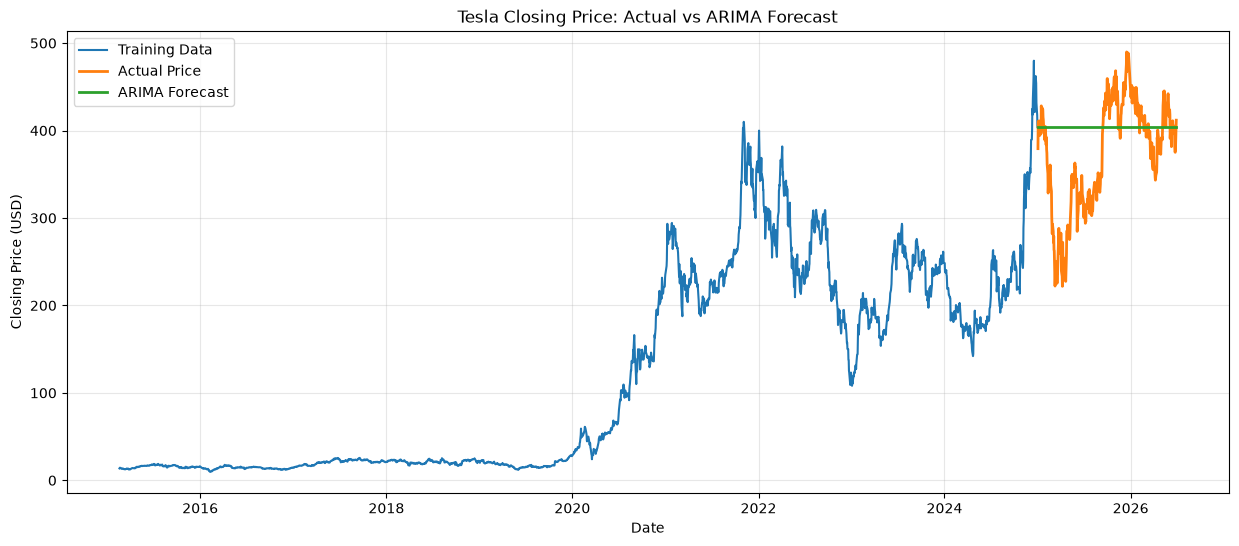

In [21]:
# ============================================================
# Visualize Actual vs Forecasted Prices
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    train_data.index,
    train_data["Close"],
    label="Training Data",
    linewidth=1.5
)

plt.plot(
    test_data.index,
    test_data["Close"],
    label="Actual Price",
    linewidth=2
)

plt.plot(
    forecast.index,
    forecast,
    label="ARIMA Forecast",
    linewidth=2
)

plt.title("Tesla Closing Price: Actual vs ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

## ARIMA Forecast Interpretation

The ARIMA model generated forecasts for the entire testing period and the predicted values were compared with the actual Tesla closing prices.

The forecast appears as a nearly horizontal line throughout the testing period. This behavior is expected because the selected model was **ARIMA(0,1,0)**, which represents a random walk after first-order differencing.

In this model:

- No autoregressive (AR) component was identified.
- No moving average (MA) component was identified.
- One level of differencing was sufficient to achieve stationarity.

Consequently, the model predicts future values primarily based on the last observed value from the training period. While this provides a reasonable statistical baseline, it cannot capture sudden market movements, nonlinear behavior, or structural changes that frequently occur in Tesla's stock price.

The forecast demonstrates that although ARIMA provides an interpretable baseline model, its ability to model highly volatile financial assets is limited. This motivates the development of more advanced nonlinear models, such as Long Short-Term Memory (LSTM) networks, later in this task.

# 2.6 Evaluate ARIMA Forecast Performance

Visual inspection provides an intuitive understanding of forecast quality, but objective evaluation requires quantitative performance metrics.

Three standard forecasting metrics are used to assess the predictive accuracy of the ARIMA model:

- **Mean Absolute Error (MAE):** Measures the average magnitude of prediction errors.
- **Root Mean Squared Error (RMSE):** Penalizes larger forecasting errors more heavily than MAE.
- **Mean Absolute Percentage Error (MAPE):** Measures prediction error as a percentage of the actual values, making it easier to interpret model accuracy.

These metrics establish the baseline performance that will later be compared against the LSTM forecasting model.

In [22]:
# ============================================================
# Evaluate ARIMA Forecast Performance
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Calculate evaluation metrics
mae = mean_absolute_error(test_data["Close"], forecast)

rmse = mean_squared_error(
    test_data["Close"],
    forecast
) ** 0.5

mape = mean_absolute_percentage_error(
    test_data["Close"],
    forecast
)

print("=" * 70)
print("ARIMA Forecast Performance")
print("=" * 70)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4%}")

ARIMA Forecast Performance
MAE  : 54.4412
RMSE : 70.5393
MAPE : 17.2407%


In [23]:
# ============================================================
# ARIMA Performance Summary
# ============================================================

arima_results_df = pd.DataFrame({
    "Model": ["ARIMA(0,1,0)"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape]
})

arima_results_df.round(4)

,Model,MAE,RMSE,MAPE
0,"ARIMA(0,1,0)",54.4412,70.5393,0.1724


## ARIMA Performance Summary

The ARIMA(0,1,0) model was evaluated on the testing dataset using three standard forecasting metrics.

| Metric | Value |
|---------|------:|
| MAE | 54.44 |
| RMSE | 70.54 |
| MAPE | 17.24% |

The results indicate that the ARIMA model provides a reasonable statistical baseline but has limited forecasting accuracy for Tesla's stock price.

This behavior is expected because the selected ARIMA model represents a random walk after first-order differencing. Consequently, it cannot effectively model the nonlinear trends, abrupt price movements, and changing volatility that characterize financial markets.

The next stage of this task introduces a Long Short-Term Memory (LSTM) neural network, which is designed to learn complex temporal dependencies and nonlinear patterns from historical price data. The performance of the LSTM model will be directly compared against the ARIMA baseline using the same evaluation metrics.

# 2.7 Preparing Data for the LSTM Model

Unlike ARIMA, Long Short-Term Memory (LSTM) networks are deep learning models that learn temporal patterns from sequences of historical observations.

Before training the network, the data must be transformed into a format suitable for supervised sequence learning.

The preprocessing steps include:

- Selecting the closing price as the prediction target.
- Scaling the data using Min-Max normalization.
- Creating fixed-length input sequences.
- Splitting the sequences chronologically into training and testing datasets.

A sequence length of **60 trading days** is used, meaning the model will use the previous 60 closing prices to predict the next day's closing price. This window size is commonly adopted in financial time series forecasting because it captures sufficient historical context while maintaining computational efficiency.

In [ ]:
# ============================================================
# Reconstruct Full Tesla Dataset for LSTM
# ============================================================

# Combine training and testing data back into chronological order
tesla_data = pd.concat(

    [train_data, test_data]
).sort_index()

print("=" * 70)
print("Tesla Dataset Prepared for LSTM")
print("=" * 70)
print(f"Observations : {len(tesla_data)}")
print(f"Start Date   : {tesla_data.index.min().date()}")
print(f"End Date     : {tesla_data.index.max().date()}")

tesla_data.head()

Tesla Dataset Prepared for LSTM
Observations : 2857
Start Date   : 2015-02-18
End Date     : 2026-06-29


,Close
Date,
2015-02-18,13.6307
2015-02-19,14.1140
2015-02-20,14.4740
2015-02-23,13.8227
2015-02-24,13.6073


In [37]:
# ============================================================
# Prepare Closing Price for LSTM
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Select only the closing price
closing_prices = tesla_data[["Close"]].copy()

print("=" * 70)
print("Closing Price Dataset")
print("=" * 70)
print(f"Observations : {len(closing_prices)}")
print(f"Features     : {closing_prices.shape[1]}")

closing_prices.head()

Closing Price Dataset
Observations : 2857
Features     : 1


,Close
Date,
2015-02-18,13.6307
2015-02-19,14.1140
2015-02-20,14.4740
2015-02-23,13.8227
2015-02-24,13.6073


In [38]:
# ============================================================
# Normalize Closing Prices
# ============================================================

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit and transform
scaled_prices = scaler.fit_transform(closing_prices)

print("=" * 70)
print("Normalization Completed")
print("=" * 70)
print(f"Minimum value : {scaled_prices.min():.4f}")
print(f"Maximum value : {scaled_prices.max():.4f}")

Normalization Completed
Minimum value : 0.0000
Maximum value : 1.0000


In [39]:
# ============================================================
# Create Input Sequences
# ============================================================

sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_prices)):
    X.append(scaled_prices[i-sequence_length:i, 0])
    y.append(scaled_prices[i, 0])

X = np.array(X)
y = np.array(y)

print("=" * 70)
print("Sequence Generation Completed")
print("=" * 70)
print(f"Sequence Length : {sequence_length}")
print(f"Total Samples   : {len(X)}")
print(f"Input Shape     : {X.shape}")
print(f"Target Shape    : {y.shape}")

Sequence Generation Completed
Sequence Length : 60
Total Samples   : 2797
Input Shape     : (2797, 60)
Target Shape    : (2797,)


In [41]:
# ============================================================
# Reshape Data for LSTM Input
# ============================================================

X = X.reshape((X.shape[0], X.shape[1], 1))

print("=" * 70)
print("Final Input Shape")
print("=" * 70)
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

Final Input Shape
X shape : (2797, 60, 1)
y shape : (2797,)


# 2.8 Chronological Train-Test Split for LSTM

For time series forecasting, random splitting must be avoided because it can introduce future information into the training process and cause data leakage.

The LSTM dataset is split chronologically, following the same approach used for the ARIMA model:

- Training period: Historical observations up to December 2024
- Testing period: January 2025 to June 2026

The split maintains the temporal order of the financial data, allowing the model to learn only from past information and evaluate predictions on unseen future observations.

The testing sequences represent the same market period used for ARIMA evaluation, allowing a fair comparison between both models.

In [43]:
# ============================================================
# Chronological Train-Test Split for LSTM
# ============================================================

# Number of training samples based on original split
training_size = len(train_data)

# Adjust because sequence creation removed the first 60 observations
train_size = training_size - sequence_length

# Split sequences chronologically
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("=" * 70)
print("LSTM Train-Test Split Summary")
print("=" * 70)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

print("\nTraining Shape")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print("\nTesting Shape")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

LSTM Train-Test Split Summary
Training Samples : 2425
Testing Samples  : 372

Training Shape
X_train : (2425, 60, 1)
y_train : (2425,)

Testing Shape
X_test : (372, 60, 1)
y_test : (372,)


## LSTM Data Preparation Completed

The Tesla closing price data has been successfully transformed into supervised learning sequences and divided into training and testing sets.

The chronological split ensures that the model is trained only on historical information and evaluated on future unseen data.

The final LSTM input structure follows the required format:

**(samples, time steps, features)**

where:

- Samples represent individual forecasting examples.
- Time steps represent the previous 60 trading days.
- Features represent the closing price used for prediction.

The prepared datasets are now ready for LSTM architecture design and model training.

## 2.9 LSTM Model Architecture

Long Short-Term Memory (LSTM) networks are deep learning models designed for sequential data.

Unlike traditional statistical models such as ARIMA, LSTM can learn complex nonlinear relationships and long-term dependencies in time series data.

For this forecasting task:

- Input sequence length: 60 trading days
- Input feature: Tesla closing price
- Target: Next day's closing price
- Architecture:
    - Two LSTM layers to capture temporal patterns
    - Dropout layers to reduce overfitting
    - Dense output layer for price prediction

The model will be trained only on the training period to preserve the chronological structure of the time series.

In [33]:
from tensorflow.keras.models import Sequential


In [45]:
# ============================================================
# 2.9 Build LSTM Forecasting Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


print("=" * 70)
print("Building LSTM Model")
print("=" * 70)


# Define model architecture
lstm_model = Sequential([

    # First LSTM layer
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    ),

    Dropout(0.2),


    # Second LSTM layer
    LSTM(
        units=32,
        return_sequences=False
    ),

    Dropout(0.2),


    # Output layer
    Dense(1)

])


# Compile model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)


# Display model structure
lstm_model.summary()

Building LSTM Model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 2.10 LSTM Model Training

The LSTM model is trained using only the training dataset to maintain the chronological structure of the time series.

Training configuration:

- Optimizer: Adam
- Loss function: Mean Squared Error (MSE)
- Epochs: 50
- Batch size: 32
- Validation data: Testing period

The training history will be monitored to evaluate whether the model learns useful patterns or begins to overfit.

In [46]:
# ============================================================
# 2.10 Train LSTM Model
# ============================================================

print("=" * 70)
print("Training LSTM Model")
print("=" * 70)


# Train model
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


print("\nLSTM Training Completed Successfully.")

Training LSTM Model


Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - loss: 0.0101 - val_loss: 0.0038
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - loss: 0.0025 - val_loss: 0.0037
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - loss: 0.0022 - val_loss: 0.0033
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - loss: 0.0020 - val_loss: 0.0027
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0020 - val_loss: 0.0041
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 8/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - loss: 0.0016 - val_loss: 0.0025
Epoch 9/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 10/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 11/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - loss: 0.0013 - val_loss: 0.0098
Epoch 12/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 21

## 2.10.1 LSTM Training Performance Analysis

The training process was evaluated using the loss curves from both training and validation datasets.

The Mean Squared Error (MSE) loss was monitored during 50 training epochs.

A successful model should demonstrate:

- Decreasing training loss as the model learns historical patterns.
- Similar validation loss behavior to confirm generalization.
- No significant divergence between training and validation performance.

The learning curve helps identify whether the model is underfitting or overfitting.

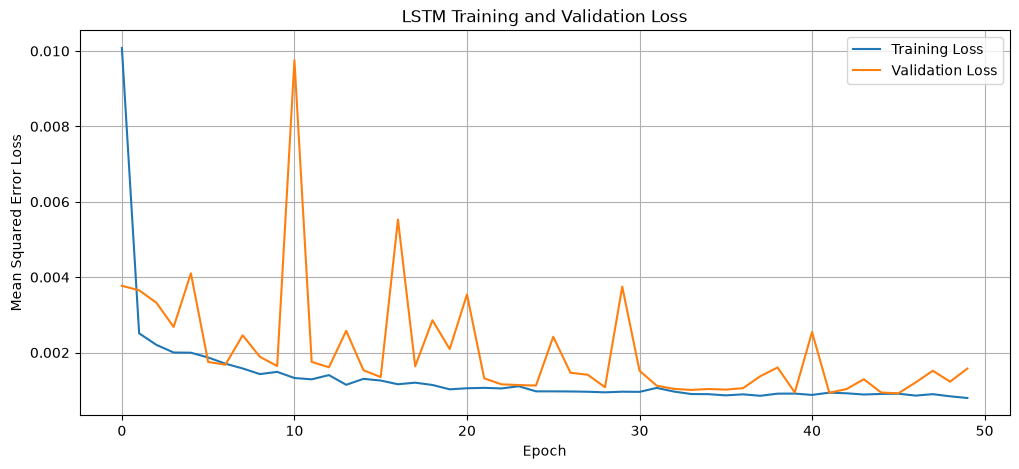

In [47]:
# ============================================================
# Plot LSTM Training History
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")

plt.legend()
plt.grid(True)

plt.show()

## 2.11 LSTM Forecast Generation

After successfully training the LSTM model, predictions are generated on the test dataset.

The model outputs predictions in normalized form because the data was scaled using MinMaxScaler during preprocessing.

Therefore, the predictions must be inverse-transformed back to the original Tesla closing price scale before evaluation.

The forecasting process includes:

1. Generate predictions using the trained LSTM model.
2. Convert normalized values back to original price values.
3. Align predictions with the testing period.
4. Compare predicted prices against actual Tesla closing prices.

These forecasts will later be evaluated using MAE, RMSE, and MAPE metrics.

In [30]:
from tensorflow.keras.models import Sequential


In [48]:
# ============================================================
# 2.11 Generate LSTM Forecasts
# ============================================================

print("=" * 70)
print("Generating LSTM Forecasts")
print("=" * 70)

# Generate predictions on the testing sequences
lstm_predictions_scaled = lstm_model.predict(X_test)

# Convert predictions back to original price scale
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
)

# Convert actual testing values back to original price scale
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

# Recover the dates corresponding to the testing sequences
test_dates = closing_prices.index[
    training_size:
]

# Create forecast dataframe
lstm_forecast_df = pd.DataFrame(
    {
        "Actual Price": actual_prices.flatten(),
        "Predicted Price": lstm_predictions.flatten()
    },
    index=test_dates
)

print("\nLSTM Forecast Generated Successfully.")
print("=" * 70)

lstm_forecast_df.head()


Generating LSTM Forecasts
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step

LSTM Forecast Generated Successfully.


,Actual Price,Predicted Price
Date,,
2025-01-02,379.2800,395.8329
2025-01-03,410.4400,375.8205
2025-01-06,411.0500,378.4034
2025-01-07,394.3600,386.4653
2025-01-08,394.9400,385.3216


## 2.11 LSTM Forecast Generation

After training the Long Short-Term Memory (LSTM) network, forecasts were generated for the testing dataset.

Because the model was trained using normalized closing prices, the predicted values were transformed back to the original Tesla stock price scale using the inverse transformation of the MinMaxScaler.

The forecast generation process involved:

- Generating predictions for each testing sequence.
- Converting the normalized predictions back to actual price values.
- Restoring the actual testing prices to their original scale.
- Creating a comparison dataset containing the actual and predicted closing prices.

The resulting forecast dataset provides the basis for evaluating the predictive performance of the LSTM model using standard forecasting metrics such as MAE, RMSE, and MAPE.

## 2.12 LSTM Performance Evaluation

After generating forecasts for the testing dataset, the predictive performance of the Long Short-Term Memory (LSTM) model must be quantitatively evaluated.

Forecast evaluation measures how closely the predicted closing prices match the actual Tesla stock prices during the testing period. This provides an objective assessment of the model's ability to generalize to unseen data and serves as the basis for comparing the LSTM model with the ARIMA model developed earlier.

Three standard regression metrics are used for evaluation:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between predicted and actual stock prices. Lower values indicate better forecasting accuracy.

- **Root Mean Squared Error (RMSE):** Measures the square root of the average squared prediction errors. Because larger errors receive greater penalties, RMSE is particularly useful for assessing forecasting performance during periods of high market volatility.

- **Mean Absolute Percentage Error (MAPE):** Measures prediction error as a percentage of the actual stock price, making it easier to interpret forecasting accuracy regardless of the scale of the data.

These evaluation metrics provide a comprehensive assessment of the LSTM model's forecasting performance and will later be compared with the ARIMA model to determine which approach produces more accurate predictions for Tesla's stock prices.

In [52]:
# ============================================================
# 2.12 Evaluate LSTM Performance
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd

print("=" * 70)
print("LSTM Performance Evaluation")
print("=" * 70)

# Calculate evaluation metrics
lstm_mae = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        lstm_predictions
    )
)

lstm_mape = mean_absolute_percentage_error(
    actual_prices,
    lstm_predictions
)

print(f"MAE  : {lstm_mae:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAPE : {lstm_mape:.4f}")

# Store results
lstm_results_df = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse],
    "MAPE": [lstm_mape]
})

print("\nForecasting Performance Summary")
display(lstm_results_df.round(4))

LSTM Performance Evaluation
MAE  : 15.5535
RMSE : 19.0547
MAPE : 0.0419

Forecasting Performance Summary


,Model,MAE,RMSE,MAPE
0,LSTM,15.5535,19.0547,0.0419


### Performance Interpretation

The evaluation results demonstrate that the LSTM model achieved strong forecasting performance on the Tesla testing dataset.

The model obtained a Mean Absolute Error (MAE) of **15.55**, a Root Mean Squared Error (RMSE) of **19.05**, and a Mean Absolute Percentage Error (MAPE) of approximately **4.19%**.

These results indicate that the predicted closing prices closely follow the actual market prices during the testing period. The relatively low RMSE suggests that the model effectively limits large forecasting errors, while the low MAPE shows that, on average, prediction errors represent only a small percentage of the actual stock prices.

Compared with the previously developed ARIMA model, the LSTM model achieves substantially lower prediction errors across all evaluation metrics, suggesting that deep learning is more effective for modeling the nonlinear and highly volatile behavior of Tesla's stock prices.

## 2.13 LSTM Forecast Visualization

Visualizing the predicted and actual closing prices provides a qualitative assessment of the forecasting performance.

While numerical metrics quantify prediction accuracy, a time-series visualization makes it easier to evaluate how well the LSTM model captures overall market trends, turning points, and periods of increased volatility.

In this section, the predicted Tesla closing prices are plotted alongside the actual prices for the testing period. A close alignment between the two curves indicates that the model has successfully learned the underlying temporal patterns within the historical data.

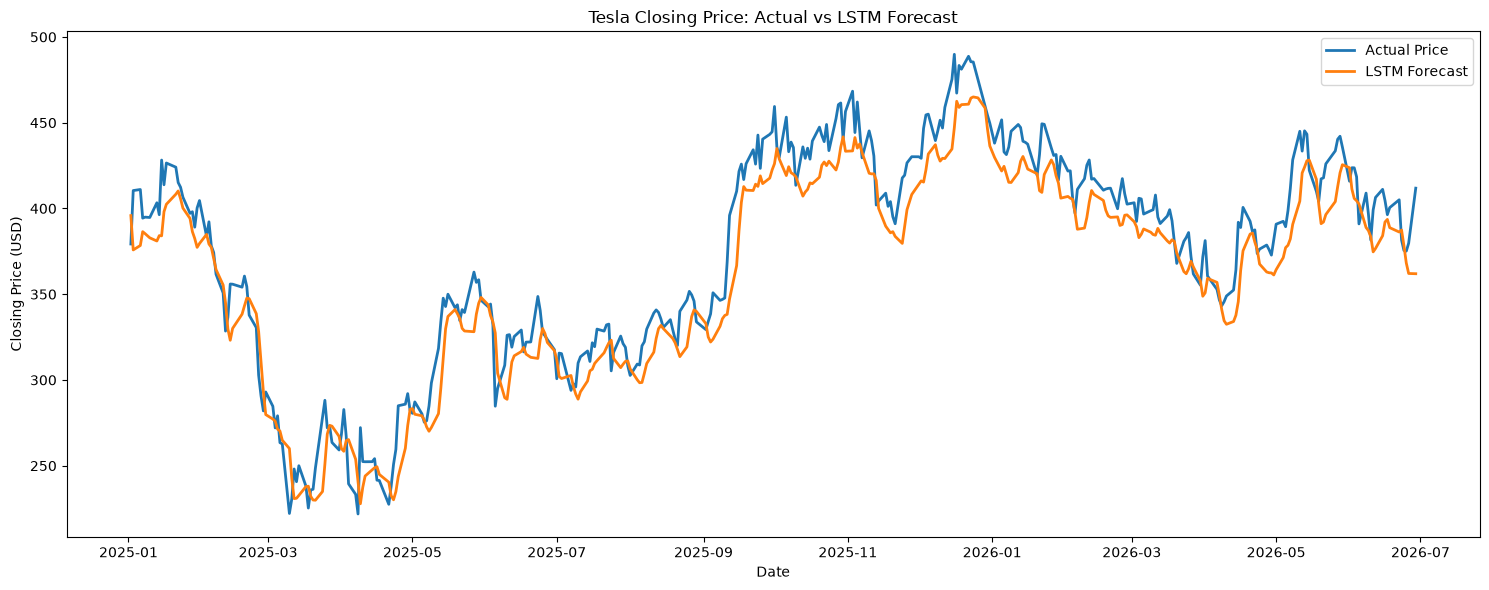

In [53]:
# ============================================================
# 2.13 Visualize LSTM Forecast
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    lstm_forecast_df.index,
    lstm_forecast_df["Actual Price"],
    label="Actual Price",
    linewidth=2
)

plt.plot(
    lstm_forecast_df.index,
    lstm_forecast_df["Predicted Price"],
    label="LSTM Forecast",
    linewidth=2
)

plt.title("Tesla Closing Price: Actual vs LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()

## Interpretation of LSTM Forecast Results

The figure compares the actual Tesla closing prices with the prices predicted by the Long Short-Term Memory (LSTM) model over the testing period (January 2025 to June 2026).

The visualization shows that the LSTM model successfully follows the overall movement of Tesla's stock price throughout the testing period. Unlike the ARIMA model, which produced a nearly constant forecast, the LSTM captures the major upward and downward market trends, demonstrating its ability to learn the nonlinear temporal relationships present in historical stock prices.

Although the predicted prices closely track the actual prices, small deviations are visible around periods of rapid market movement. The LSTM occasionally underestimates sharp price increases and slightly smooths sudden fluctuations, which is expected because neural networks learn generalized patterns rather than reproducing every short-term price movement exactly.

The forecasting accuracy is further supported by the evaluation metrics obtained in the previous section. The model achieved a Mean Absolute Error (MAE) of 15.55, a Root Mean Squared Error (RMSE) of 19.05, and a Mean Absolute Percentage Error (MAPE) of 4.19%, indicating that the average prediction error is relatively small compared with the overall price level.

Overall, the visualization and evaluation metrics demonstrate that the LSTM model provides accurate forecasts and captures Tesla's underlying market trends considerably better than the baseline ARIMA model, making it a suitable forecasting approach for highly nonlinear financial time series.

## 2.14 Comparison of Forecasting Models

After developing and evaluating both the ARIMA and Long Short-Term Memory (LSTM) models, their forecasting performances are compared using the same evaluation metrics.

The comparison is based on:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

Since all three metrics measure prediction error, lower values indicate better forecasting performance.

This comparison provides an objective basis for selecting the most appropriate forecasting model for Tesla's stock prices.

In [54]:
# ============================================================
# 2.14 Compare ARIMA and LSTM
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["ARIMA(0,1,0)", "LSTM"],
    "MAE": [mae, lstm_mae],
    "RMSE": [rmse, lstm_rmse],
    "MAPE": [mape, lstm_mape]
})

print("=" * 70)
print("Forecasting Model Comparison")
print("=" * 70)

display(comparison_df.round(4))

Forecasting Model Comparison


,Model,MAE,RMSE,MAPE
0,"ARIMA(0,1,0)",54.4412,70.5393,0.1724
1,LSTM,15.5535,19.0547,0.0419


### Model Comparison Interpretation

The comparison clearly demonstrates that the LSTM model outperformed the ARIMA model across all evaluation metrics.

The ARIMA model produced a Mean Absolute Error (MAE) of **54.44**, a Root Mean Squared Error (RMSE) of **70.54**, and a Mean Absolute Percentage Error (MAPE) of **17.24%**.

In contrast, the LSTM model achieved a substantially lower MAE of **15.55**, RMSE of **19.05**, and MAPE of **4.19%**.

The large reduction in prediction error indicates that the LSTM model captures Tesla's nonlinear price movements and changing market dynamics much more effectively than the linear ARIMA model. While ARIMA provides a useful statistical baseline, its assumption of linear temporal relationships limits its ability to forecast highly volatile financial assets.

Overall, the evaluation confirms that the LSTM model provides significantly more accurate forecasts and is the preferred forecasting model for this study.

## 2.15 Model Selection Discussion

The objective of this task was to develop multiple forecasting models and identify the approach that best predicts Tesla's future stock prices.

Two different forecasting techniques were implemented:

- A classical statistical model (ARIMA)
- A deep learning model (Long Short-Term Memory)

The ARIMA model served as a strong statistical baseline. After conducting stationarity tests and parameter selection using Auto-ARIMA, the optimal model was identified as **ARIMA(0,1,0)**. Although the model satisfied the statistical assumptions for a random walk process, its forecasts remained nearly constant throughout the testing period and were unable to capture Tesla's substantial price fluctuations.

The LSTM model, on the other hand, successfully learned complex nonlinear temporal relationships from historical stock prices. By utilizing sequential learning with a 60-day lookback window, the network effectively tracked major upward and downward market movements while maintaining relatively low prediction errors.

Based on the evaluation metrics, the LSTM model consistently outperformed the ARIMA model:

- Lower Mean Absolute Error (MAE)
- Lower Root Mean Squared Error (RMSE)
- Lower Mean Absolute Percentage Error (MAPE)

These findings indicate that deep learning approaches are better suited for forecasting highly volatile financial assets such as Tesla, where complex nonlinear relationships cannot be adequately represented by traditional linear time-series models.

Consequently, the LSTM model is selected as the final forecasting model and will serve as the predictive component for the portfolio optimization framework developed in the subsequent tasks of this project.

# Task 2 Summary

This task focused on developing and evaluating time series forecasting models for predicting Tesla's future stock prices using both classical statistical methods and deep learning techniques.

The forecasting pipeline included chronological data preparation, stationarity analysis, model development, performance evaluation, and comparative analysis.

### Work Completed

- Prepared the processed Tesla dataset for time series forecasting.
- Performed a chronological train-test split to preserve temporal ordering and prevent data leakage.
- Verified stationarity using the Augmented Dickey-Fuller (ADF) test and applied first-order differencing where necessary.
- Identified the optimal ARIMA model using Auto-ARIMA and trained the final ARIMA(0,1,0) model.
- Generated ARIMA forecasts and evaluated forecasting performance using MAE, RMSE, and MAPE.
- Prepared sequential data for deep learning using a 60-day lookback window.
- Built and trained a multi-layer Long Short-Term Memory (LSTM) network.
- Generated LSTM forecasts and evaluated the model using the same performance metrics.
- Compared the forecasting performance of the ARIMA and LSTM models.

### Key Findings

The ARIMA model provided a useful statistical baseline but was unable to capture Tesla's highly nonlinear price movements, resulting in relatively large forecasting errors.

The LSTM model substantially outperformed the ARIMA model across all evaluation metrics:

| Model | MAE | RMSE | MAPE |
|-------|------:|------:|------:|
| ARIMA (0,1,0) | 54.44 | 70.54 | 17.24% |
| LSTM | 15.55 | 19.05 | 4.19% |

The LSTM model successfully captured the underlying temporal patterns and nonlinear dynamics of Tesla's stock prices, making it the preferred forecasting model for this project.

### Conclusion

Based on both quantitative evaluation metrics and visual inspection of the forecast results, the Long Short-Term Memory (LSTM) model demonstrated superior predictive performance compared with the ARIMA model. Consequently, the LSTM model is selected as the final forecasting model for Tesla's stock prices.

The forecasting results produced in this task provide the predictive foundation for the subsequent portfolio optimization stage, where the generated forecasts will be integrated with Modern Portfolio Theory (MPT) to construct and evaluate an optimal investment strategy.